In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import os

# ------------------ 1. Загрузка данных из обработанного CSV ------------------
DATA_PATH = 'data/processed/siddha_processed.csv'
df = pd.read_csv(DATA_PATH)  # колонки: user_id, activity, timestamp, gyro_x, gyro_y, gyro_z, acc_x, acc_y, acc_z

# Убедимся, что нет пропусков и нулевых временных меток (на всякий случай)
df = df.dropna()
#df = df[df['timestamp'] != 0]

# Сортируем по пользователю и времени (уже должно быть, но гарантируем)
df = df.sort_values(['user_id', 'activity', 'timestamp']).reset_index(drop=True)

# ------------------ 2. Создание окон ------------------
WINDOW_SIZE = 200
STEP = 100  # перекрытие 50%

# Признаки: все, кроме user_id, activity, timestamp
feature_cols = ['gyro_x', 'gyro_y', 'gyro_z', 'acc_x', 'acc_y', 'acc_z']

X_windows = []    # окна (WINDOW_SIZE, 6)
y_windows = []    # метки активности (уже числа 0..4)
user_windows = [] # ID пользователя для каждого окна

# Группируем по пользователю (данные внутри группы уже отсортированы по времени)
for user_id, group in df.groupby('user_id'):
    # Извлекаем массивы признаков и меток
    data = group[feature_cols].values        # shape (n, 6)
    activities = group['activity'].values    # shape (n,)
    
    n = len(data)
    if n < WINDOW_SIZE:
        continue  # недостаточно данных
    
    # Проходим по последовательности с шагом STEP
    for start in range(0, n - WINDOW_SIZE + 1, STEP):
        end = start + WINDOW_SIZE
        window_activities = activities[start:end]
        
        # Проверяем, что все активности в окне одинаковы
        if np.all(window_activities == window_activities[0]):
            X_windows.append(data[start:end])
            y_windows.append(window_activities[0])
            user_windows.append(user_id)

# Преобразуем в numpy
X_windows = np.array(X_windows)   # (num_windows, WINDOW_SIZE, 6)
y_windows = np.array(y_windows)   # (num_windows,)
user_windows = np.array(user_windows)

print(X_windows.shape)

print(f"Всего окон: {len(X_windows)}")
print(f"Уникальных пользователей с окнами: {len(np.unique(user_windows))}")

def split_and_scale_by_user(user_test, X_windows, y_windows, user_windows, WINDOW_SIZE, random_state=42):
    """
    Для заданного пользователя user_test:
      - он становится тестовым
      - из оставшихся выбирается один пользователь для валидации (только среди тех, у кого есть все активности)
      - остальные (все оставшиеся) – тренировка
    Возвращает:
      X_train_scaled, y_train, X_val_scaled, y_val, X_test_scaled, y_test
    """
    all_users = np.unique(user_windows)
    all_activities = np.unique(y_windows)
    
    # Определяем пользователей с полным набором активностей
    full_users = []
    for u in all_users:
        mask = (user_windows == u)
        user_acts = np.unique(y_windows[mask])
        if set(user_acts) == set(all_activities):
            full_users.append(u)
    
    # Исключаем тестового пользователя из списка для валидации
    candidates_for_val = [u for u in full_users if u != user_test]
    
    if len(candidates_for_val) == 0:
        raise ValueError(f"Нет пользователей с полным набором активностей для валидации (кроме тестового {user_test})")
    
    # Случайно выбираем одного валидационного из кандидатов
    rng = np.random.RandomState(random_state)
    val_user = rng.choice(candidates_for_val, 1)[0]
    
    # Все остальные пользователи (включая тех, у кого неполный набор) идут в тренировку, кроме тестового и валидационного
    train_users = [u for u in all_users if u != user_test and u != val_user]
    
    print(f"Test user: {user_test}, Val user: {val_user}, Train users: {len(train_users)}")
    
    # Фильтруем окна
    train_mask = np.isin(user_windows, train_users)
    val_mask = (user_windows == val_user)
    test_mask = (user_windows == user_test)
    
    X_train = X_windows[train_mask]
    y_train = y_windows[train_mask]
    X_val = X_windows[val_mask]
    y_val = y_windows[val_mask]
    X_test = X_windows[test_mask]
    y_test = y_windows[test_mask]
    
    print(f"Train windows: {len(X_train)}, Val windows: {len(X_val)}, Test windows: {len(X_test)}")
    
    # ------------------ Масштабирование (только по train) ------------------
    X_train_flat = X_train.reshape(-1, 3)
    scaler = StandardScaler()
    scaler.fit(X_train_flat)
    
    def scale_data(X):
        original_shape = X.shape
        X_flat = X.reshape(-1, 3)
        X_scaled = scaler.transform(X_flat)
        return X_scaled.reshape(original_shape)
    
    X_train_scaled = scale_data(X_train)
    X_val_scaled = scale_data(X_val)
    X_test_scaled = scale_data(X_test)
    
    return X_train_scaled, y_train, X_val_scaled, y_val, X_test_scaled, y_test

(8504, 200, 6)
Всего окон: 8504
Уникальных пользователей с окнами: 51


In [2]:
# Train function

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report
import os
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

def train_model(model, model_name, train_loader, val_loader, test_loader,
                num_epochs=50, lr=0.001, device='cuda', weights=None, save_dir='models'):
    """
    Обучение с динамическим обновлением вывода (Jupyter/Colab).
    Каждая эпоха перерисовывает: прогресс, лучший F1, графики потерь и F1.
    """
    os.makedirs(save_dir, exist_ok=True)
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Total trainable parameters: {total_params}")
    
    model = model.to(device)
    if weights is not None:
        weights = weights.to(device)
    
    criterion = nn.CrossEntropyLoss(weight=weights)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=20, factor=0.5)
    
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'train_f1': [], 'val_f1': []
    }
    
    best_val_f1 = -1.0
    best_epoch = 0
    best_model_state = None

    epoch_bar = tqdm(range(1, num_epochs + 1), desc='Training', unit='epoch')
    for epoch in epoch_bar:
        # ---------- Train ----------
        model.train()
        train_losses = []
        train_preds = []
        train_labels = []
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.float().to(device)
            y_batch = y_batch.long().to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())
            preds = torch.argmax(outputs, dim=1)
            train_preds.extend(preds.cpu().numpy())
            train_labels.extend(y_batch.cpu().numpy())
        
        train_loss = np.mean(train_losses)
        train_acc = accuracy_score(train_labels, train_preds)
        train_f1 = f1_score(train_labels, train_preds, average='macro')
        
        # ---------- Validation ----------
        model.eval()
        val_losses = []
        val_preds = []
        val_labels = []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.float().to(device)
                y_batch = y_batch.long().to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_losses.append(loss.item())
                preds = torch.argmax(outputs, dim=1)
                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(y_batch.cpu().numpy())
        
        val_loss = np.mean(val_losses)
        val_acc = accuracy_score(val_labels, val_preds)
        val_f1 = f1_score(val_labels, val_preds, average='macro')
        
        # Сохраняем историю
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['train_f1'].append(train_f1)
        history['val_f1'].append(val_f1)

        scheduler.step(val_loss)
        
        # Обновляем лучшую модель
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch = epoch
            best_model_state = model.state_dict().copy()
        
        # Сохраняем историю и проверяем лучший результат
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch = epoch
            best_model_state = model.state_dict().copy()
            # Выводим строку с лучшим значением (не ломает бар)
            tqdm.write(f'⭐ Best val F1 = {best_val_f1:.4f} at epoch {best_epoch}')
        
        # Обновляем единственный прогресс-бар
        epoch_bar.set_postfix({
            'TL': f'{train_loss:.3f}',
            'VL': f'{val_loss:.3f}',
            'VF': f'{val_f1:.3f}',
            'best VF': f'{best_val_f1:.3f}' if best_val_f1 > -1 else '-',
            'best Epoch': f'{best_epoch}'
        })
    
    # ---------- Загрузка лучшей модели и сохранение ----------
    model.load_state_dict(best_model_state)
    torch.save(model.state_dict(), os.path.join(save_dir, f"{model_name}.pt"))

    # 2. Графики
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history['train_loss'], label='train')
    ax1.plot(history['val_loss'], label='val')
    ax1.set_title('Loss')
    ax1.legend()
    ax1.grid(True)
        
    ax2.plot(history['train_f1'], label='train')
    ax2.plot(history['val_f1'], label='val')
    ax2.set_title('F1 (macro)')
    ax2.legend()
    ax2.grid(True)
        
    plt.tight_layout()
    plt.show()
    
    # ---------- Тест (финальный вывод после обучения) ----------
    #clear_output(wait=True)  # очищаем последний вывод с графиками
    print(f"Training complete. Best val F1 = {best_val_f1:.4f} at epoch {best_epoch}")
    print(f"Model saved to {save_dir}/{model_name}.pt")
    
    model.eval()
    test_preds = []
    test_labels = []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.float().to(device)
            y_batch = y_batch.long().to(device)
            outputs = model(X_batch)
            preds = torch.argmax(outputs, dim=1)
            test_preds.extend(preds.cpu().numpy())
            test_labels.extend(y_batch.cpu().numpy())
    
    print("\n========== Test Set Evaluation ==========")
    print(classification_report(test_labels, test_preds, digits=4))
    test_acc = accuracy_score(test_labels, test_preds)
    test_f1_macro = f1_score(test_labels, test_preds, average='macro')
    test_precision_macro = precision_score(test_labels, test_preds, average='macro')
    test_recall_macro = recall_score(test_labels, test_preds, average='macro')
    print(f"Overall Accuracy: {test_acc:.4f}")
    print(f"Macro Precision: {test_precision_macro:.4f}")
    print(f"Macro Recall:    {test_recall_macro:.4f}")
    print(f"Macro F1:        {test_f1_macro:.4f}")
    print("==========================================")
    
    return model, history, test_f1_macro

In [3]:
from ncps.torch import CfC

class LNNConvClassifier(nn.Module):
    def __init__(self, input_size, hidden_units, num_classes, dropout_rate=0.3):
        super(LNNConvClassifier, self).__init__()
        self.cfc = CfC(input_size=input_size, units=hidden_units)
        
        # Три 1D свертки с уменьшением временной размерности в 2 раза после каждой
        self.conv1 = nn.Sequential(
            nn.Conv1d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.BatchNorm1d(hidden_units),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.MaxPool1d(kernel_size=2, stride=2)  # уменьшает длину вдвое
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.BatchNorm1d(hidden_units),
            nn.ReLU(inplace=True),
            #nn.Dropout(dropout_rate),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )
        self.conv3 = nn.Sequential(
            nn.Conv1d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.BatchNorm1d(hidden_units),
            nn.ReLU(inplace=True),
            #nn.Dropout(dropout_rate),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )
        # Глобальный макс пулинг в конце
        self.global_max_pool = nn.AdaptiveMaxPool1d(1)
        self.dropout_cl = nn.Dropout(0.5)
        self.classifier = nn.Linear(hidden_units, num_classes)
        
    def forward(self, x):
        # x: (batch, seq_len, input_size)
        outputs, _ = self.cfc(x)          # (batch, seq_len, hidden_units)
        # Переставляем для 1D сверток: (batch, hidden_units, seq_len)
        out = outputs.permute(0, 2, 1)
        out = self.conv1(out)
        out = self.conv2(out)
        out = self.conv3(out)
        out = self.global_max_pool(out)   # (batch, hidden_units, 1)
        out = out.squeeze(-1)             # (batch, hidden_units)
        oot = self.dropout_cl(out)
        return self.classifier(out)

In [4]:
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

np.random.seed(42)

all_users = np.unique(user_windows)
all_activities = np.unique(y_windows)

in_params, hidden, out = 6, 16, 5

def train_by_test_user(user):
    X_train_scaled, y_train, X_val_scaled, y_val, X_test_scaled, y_test = split_and_scale_by_user(user, X_windows, y_windows, user_windows, WINDOW_SIZE)

    # Предполагается, что X_train_scaled, X_val_scaled, X_test_scaled,
    # y_train, y_val, y_test уже существуют (из предыдущего шага)
    
    # ------------------ Преобразование в тензоры ------------------
    X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
    X_val_t   = torch.tensor(X_val_scaled,   dtype=torch.float32)
    X_test_t  = torch.tensor(X_test_scaled,  dtype=torch.float32)
    
    y_train_t = torch.tensor(y_train, dtype=torch.long)
    y_val_t   = torch.tensor(y_val,   dtype=torch.long)
    y_test_t  = torch.tensor(y_test,  dtype=torch.long)
    
    # ------------------ Создание DataLoader ------------------
    batch_size = 9000
    
    train_dataset = TensorDataset(X_train_t, y_train_t)
    val_dataset   = TensorDataset(X_val_t, y_val_t)
    test_dataset  = TensorDataset(X_test_t, y_test_t)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)
    
    # ------------------ Расчёт весов классов (по train) ------------------
    classes = np.unique(y_train)
    class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
    weights_tensor = torch.tensor(class_weights, dtype=torch.float32)
    
    print(f"Class weights: {weights_tensor}")
    
    # ------------------ Создание модели и вывод параметров ------------------
    #model = SimpleCNN(num_classes=6)
    #model_name='wisdm_simple_cnn'
    
    #model = LNNClassifier(3, 16, 6)
    #model_name='wisdm_lnn'
    
    model = LNNConvClassifier(in_params, hidden, out)
    model_name='siddha_lnn_conv'
    
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    best_model, history, test_f1_macro = train_model(
        model=model,
        model_name=model_name,
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        num_epochs=300,
        lr=1e-3,
        device=device,
        weights=weights_tensor,
        save_dir='models'
    )

    return model, X_test_scaled, y_test

import time

def finetune_last_layer(base_model, X_user, y_user, num_samples_per_class=2, epochs=20, lr=1e-4):
    """
    Дообучение последнего слоя модели на выбранных примерах пользователя (только CPU).
    
    Аргументы:
        base_model: обученная модель (с весами)
        X_user: массив окон пользователя (n, WINDOW_SIZE, 3)
        y_user: метки активностей для этих окон
        num_samples_per_class: сколько окон брать на класс
        epochs: число эпох дообучения
        lr: скорость обучения
    Возвращает:
        finetuned_model: модель с обновлённым последним слоем
    """
    device = 'cpu'
    base_model = base_model.to(device)
    
    # 1. Выбираем по num_samples_per_class окон для каждого класса
    unique_classes = np.unique(y_user)
    X_finetune = []
    y_finetune = []
    
    for cls in unique_classes:
        indices = np.where(y_user == cls)[0]
        if len(indices) < num_samples_per_class:
            print(f"Предупреждение: для класса {cls} всего {len(indices)} окон, берём все")
            selected = indices
        else:
            selected = np.random.choice(indices, num_samples_per_class, replace=False)
        X_finetune.append(X_user[selected])
        y_finetune.append(y_user[selected])
    
    X_finetune = np.vstack(X_finetune)  # (N, WINDOW_SIZE, 3)
    y_finetune = np.hstack(y_finetune)  # (N,)
    
    print(f"Данных для дообучения: {len(X_finetune)} окон")
    
    # 2. Создаём новую модель и копируем веса из base_model
    finetuned_model = LNNConvClassifier(in_params, hidden, out) # должно совпадать с исходной моделью
    finetuned_model.load_state_dict(base_model.state_dict())
    finetuned_model = finetuned_model.to(device)
    
    # 3. Замораживаем все слои, кроме classifier
    #for name, param in finetuned_model.named_parameters():
    #    if not name.startswith('classifier'):
    #        param.requires_grad = False
    #    else:
    #        param.requires_grad = True
    #        print(f"Размораживаем слой: {name}")
    
    # 4. Подготовка DataLoader
    X_t = torch.tensor(X_finetune, dtype=torch.float32)
    y_t = torch.tensor(y_finetune, dtype=torch.long)
    dataset = TensorDataset(X_t, y_t)
    loader = DataLoader(dataset, batch_size=len(X_t), shuffle=True)  # все данные сразу
    
    # 5. Настройка оптимизатора – можно передать все параметры, замороженные не обновятся
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, finetuned_model.parameters()), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    # 6. Цикл обучения
    finetuned_model.train()
    start_time = time.time()
    for epoch in range(epochs):
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            optimizer.zero_grad()
            outputs = finetuned_model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
        if (epoch+1) % 5 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")
    elapsed = time.time() - start_time
    print(f"Дообучение завершено за {elapsed:.2f} сек")
    
    return finetuned_model

def evaluate_model(model, X, y, device='cpu'):
    model.eval()
    with torch.no_grad():
        X_t = torch.tensor(X, dtype=torch.float32).to(device)
        y_t = torch.tensor(y, dtype=torch.long).to(device)
        outputs = model(X_t)
        preds = torch.argmax(outputs, dim=1)
        preds_np = preds.cpu().numpy()
        y_np = y_t.cpu().numpy()
        f1_macro = f1_score(y_np, preds_np, average='macro')
    return f1_macro


Test users (which macro f1 is small): [0, 1, 3, 4, 5, 6, 7, 8, 9, 13, 14, 20, 21, 22, 24, 28, 29, 31, 33, 34, 36, 37, 38, 39, 40, 41, 42, 46, 47, 48]
Test users count: 30



Test user: 0
Test user: 0, Val user: 43, Train users: 49
Train windows: 8164, Val windows: 170, Test windows: 170
Class weights: tensor([0.9783, 0.9999, 1.0440, 0.9801, 1.0005])
Total trainable parameters: 13733


Training: 100%|██████| 300/300 [03:51<00:00,  1.30epoch/s, TL=0.111, VL=0.154, VF=0.958, best VF=0.970, best Epoch=215]


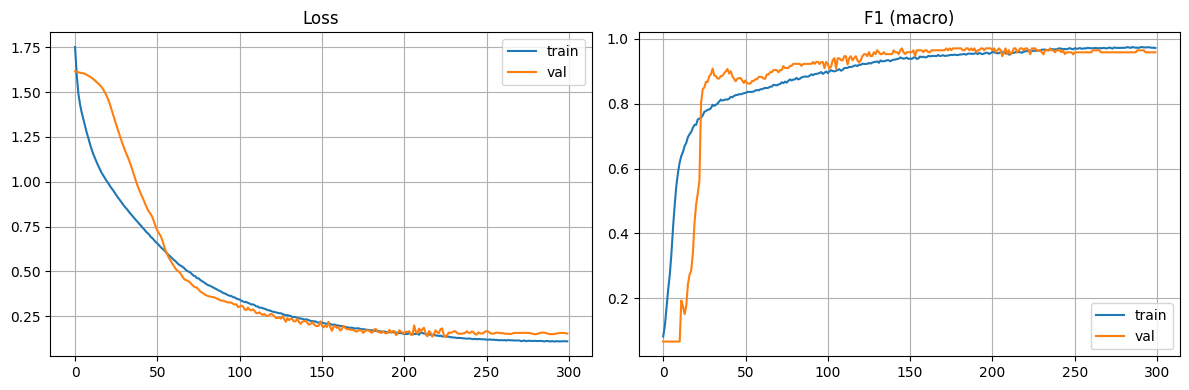

Training complete. Best val F1 = 0.9705 at epoch 215
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        34
           1     1.0000    1.0000    1.0000        34
           2     1.0000    1.0000    1.0000        34
           3     1.0000    1.0000    1.0000        34
           4     1.0000    1.0000    1.0000        34

    accuracy                         1.0000       170
   macro avg     1.0000    1.0000    1.0000       170
weighted avg     1.0000    1.0000    1.0000       170

Overall Accuracy: 1.0000
Macro Precision: 1.0000
Macro Recall:    1.0000
Macro F1:        1.0000
Данных для дообучения: 10 окон
Epoch 5/20, Loss: 0.0184
Epoch 10/20, Loss: 0.0092
Epoch 15/20, Loss: 0.0077
Epoch 20/20, Loss: 0.0065
Дообучение завершено за 3.82 сек
Macro F1 на тестовом пользователе до дообучения: 1.0000
Macro F1 после дообучения (последний слой): 0.9941





Training: 100%|██████| 300/300 [03:50<00:00,  1.30epoch/s, TL=0.206, VL=0.359, VF=0.832, best VF=0.964, best Epoch=184]


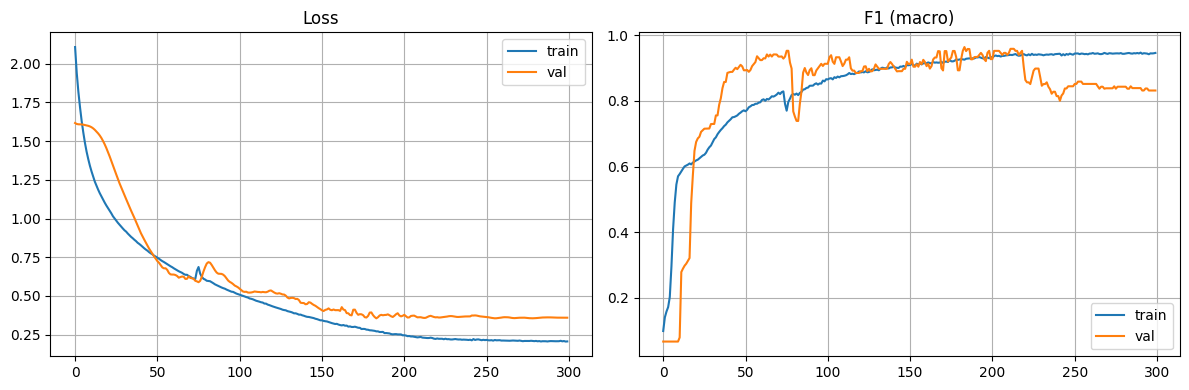

Training complete. Best val F1 = 0.9640 at epoch 184
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     1.0000    0.7059    0.8276        34
           1     1.0000    1.0000    1.0000        34
           2     0.9444    1.0000    0.9714        34
           3     0.4595    1.0000    0.6296        34
           4     1.0000    0.0588    0.1111        34

    accuracy                         0.7529       170
   macro avg     0.8808    0.7529    0.7080       170
weighted avg     0.8808    0.7529    0.7080       170

Overall Accuracy: 0.7529
Macro Precision: 0.8808
Macro Recall:    0.7529
Macro F1:        0.7080
Данных для дообучения: 10 окон
Epoch 5/20, Loss: 0.1356
Epoch 10/20, Loss: 0.1249
Epoch 15/20, Loss: 0.0949
Epoch 20/20, Loss: 0.0977
Дообучение завершено за 3.86 сек
Macro F1 на тестовом пользователе до дообучения: 0.7080
Macro F1 после дообучения (последний слой): 1.0000





Training: 100%|██████| 300/300 [03:51<00:00,  1.30epoch/s, TL=0.216, VL=0.324, VF=0.903, best VF=0.965, best Epoch=122]


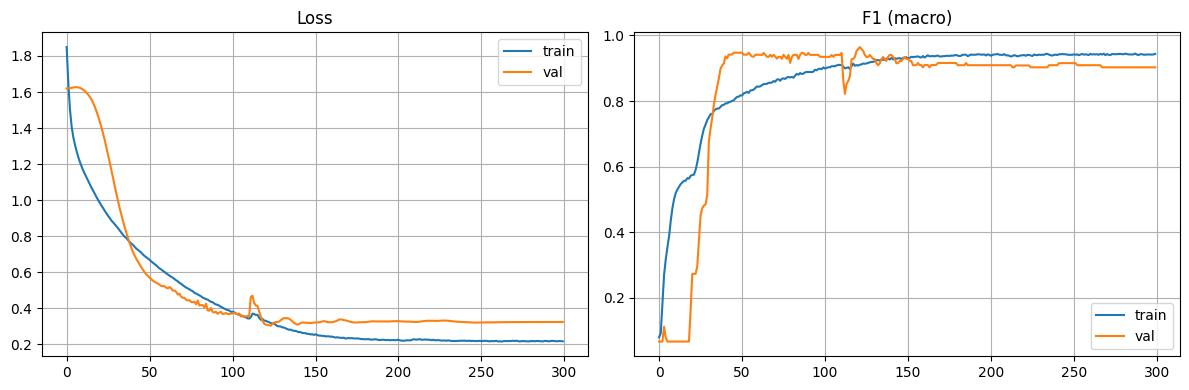

Training complete. Best val F1 = 0.9647 at epoch 122
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9444    0.9714    0.9577        35
           1     1.0000    1.0000    1.0000        34
           2     0.9667    0.8529    0.9062        34
           3     0.0000    0.0000    0.0000        34
           4     0.4789    1.0000    0.6476        34

    accuracy                         0.7661       171
   macro avg     0.6780    0.7649    0.7023       171
weighted avg     0.6796    0.7661    0.7038       171

Overall Accuracy: 0.7661
Macro Precision: 0.6780
Macro Recall:    0.7649
Macro F1:        0.7023
Данных для дообучения: 10 окон


C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

Epoch 5/20, Loss: 0.1825
Epoch 10/20, Loss: 0.1621
Epoch 15/20, Loss: 0.1217
Epoch 20/20, Loss: 0.0845
Дообучение завершено за 3.83 сек
Macro F1 на тестовом пользователе до дообучения: 0.7023
Macro F1 после дообучения (последний слой): 0.9590



Test user: 4
Test user: 4, Val user: 43, Train users: 49
Train windows: 8164, Val windows: 170, Test windows: 170
Class weights: tensor([0.9783, 0.9999, 1.0440, 0.9801, 1.0005])
Total trainable parameters: 13733


Training: 100%|██████| 300/300 [03:51<00:00,  1.30epoch/s, TL=0.162, VL=0.186, VF=0.964, best VF=0.994, best Epoch=132]


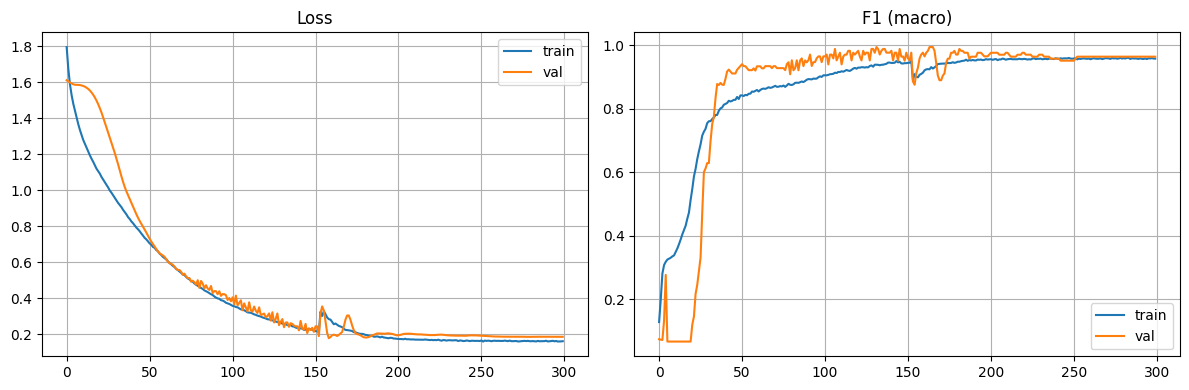

Training complete. Best val F1 = 0.9941 at epoch 132
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     1.0000    0.6176    0.7636        34
           1     1.0000    1.0000    1.0000        34
           2     0.7234    1.0000    0.8395        34
           3     0.5556    0.8824    0.6818        34
           4     0.7143    0.2941    0.4167        34

    accuracy                         0.7588       170
   macro avg     0.7986    0.7588    0.7403       170
weighted avg     0.7986    0.7588    0.7403       170

Overall Accuracy: 0.7588
Macro Precision: 0.7986
Macro Recall:    0.7588
Macro F1:        0.7403
Данных для дообучения: 10 окон
Epoch 5/20, Loss: 0.1483
Epoch 10/20, Loss: 0.0838
Epoch 15/20, Loss: 0.0692
Epoch 20/20, Loss: 0.0580
Дообучение завершено за 3.83 сек
Macro F1 на тестовом пользователе до дообучения: 0.7403
Macro F1 после дообучения (последний слой): 0.8560





Training: 100%|██████| 300/300 [03:50<00:00,  1.30epoch/s, TL=0.110, VL=0.119, VF=0.994, best VF=0.994, best Epoch=201]


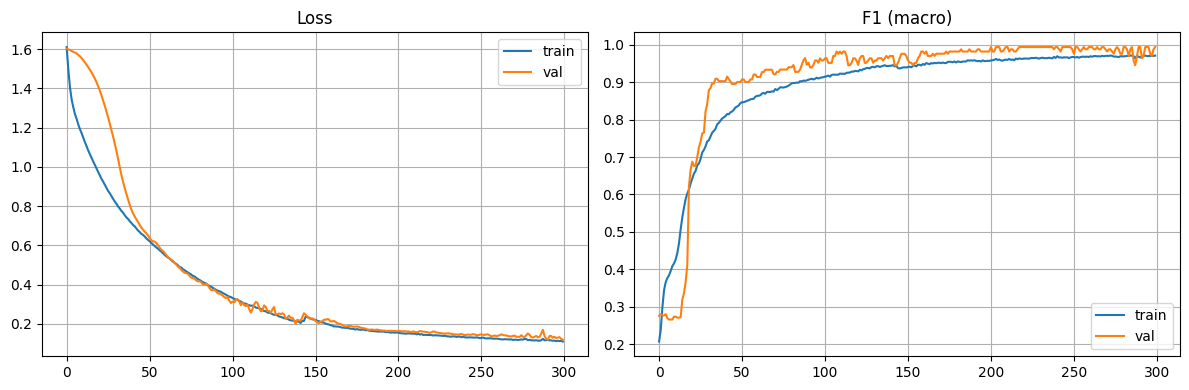

Training complete. Best val F1 = 0.9941 at epoch 201
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     1.0000    0.8857    0.9394        35
           1     1.0000    1.0000    1.0000        35
           2     0.8947    1.0000    0.9444        34
           3     1.0000    0.9706    0.9851        34
           4     0.9714    1.0000    0.9855        34

    accuracy                         0.9709       172
   macro avg     0.9732    0.9713    0.9709       172
weighted avg     0.9735    0.9709    0.9709       172

Overall Accuracy: 0.9709
Macro Precision: 0.9732
Macro Recall:    0.9713
Macro F1:        0.9709
Данных для дообучения: 10 окон
Epoch 5/20, Loss: 0.0202
Epoch 10/20, Loss: 0.0178
Epoch 15/20, Loss: 0.0124
Epoch 20/20, Loss: 0.0094
Дообучение завершено за 3.83 сек
Macro F1 на тестовом пользователе до дообучения: 0.9709
Macro F1 после дообучения (последний слой): 0.9882





Training: 100%|███████| 300/300 [03:50<00:00,  1.30epoch/s, TL=0.177, VL=0.408, VF=0.911, best VF=0.965, best Epoch=72]


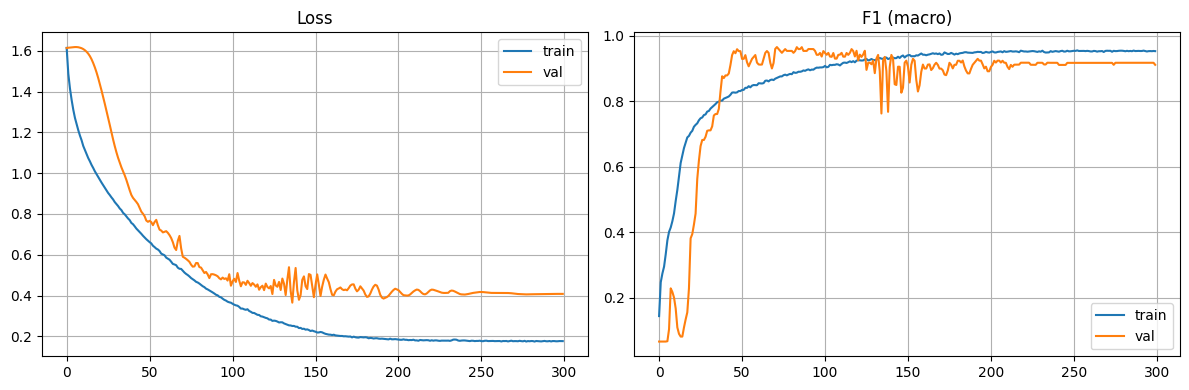

Training complete. Best val F1 = 0.9652 at epoch 72
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     1.0000    0.9706    0.9851        34
           1     1.0000    1.0000    1.0000        34
           2     0.9688    0.9118    0.9394        34
           3     0.9429    0.9706    0.9565        34
           4     0.9167    0.9706    0.9429        34

    accuracy                         0.9647       170
   macro avg     0.9657    0.9647    0.9648       170
weighted avg     0.9657    0.9647    0.9648       170

Overall Accuracy: 0.9647
Macro Precision: 0.9657
Macro Recall:    0.9647
Macro F1:        0.9648
Данных для дообучения: 10 окон
Epoch 5/20, Loss: 0.0466
Epoch 10/20, Loss: 0.0358
Epoch 15/20, Loss: 0.0344
Epoch 20/20, Loss: 0.0306
Дообучение завершено за 3.82 сек
Macro F1 на тестовом пользователе до дообучения: 0.9648
Macro F1 после дообучения (последний слой): 0.9823



T

Training: 100%|███████| 300/300 [03:51<00:00,  1.30epoch/s, TL=0.134, VL=0.168, VF=0.976, best VF=0.982, best Epoch=93]


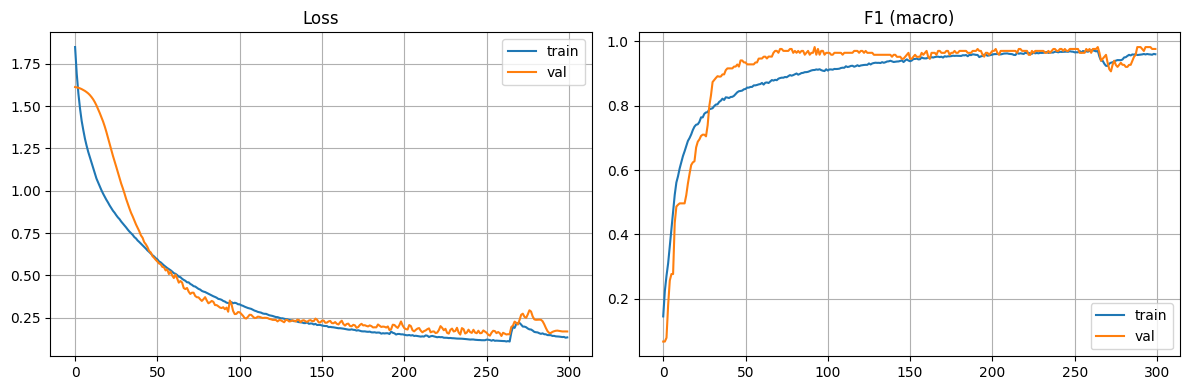

Training complete. Best val F1 = 0.9823 at epoch 93
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.8095    0.9714    0.8831        35
           1     1.0000    1.0000    1.0000        34
           2     0.8500    0.5000    0.6296        34
           3     0.6970    0.6765    0.6866        34
           4     0.7143    0.8824    0.7895        34

    accuracy                         0.8070       171
   macro avg     0.8142    0.8061    0.7978       171
weighted avg     0.8141    0.8070    0.7983       171

Overall Accuracy: 0.8070
Macro Precision: 0.8142
Macro Recall:    0.8061
Macro F1:        0.7978
Данных для дообучения: 10 окон
Epoch 5/20, Loss: 0.3373
Epoch 10/20, Loss: 0.2269
Epoch 15/20, Loss: 0.1693
Epoch 20/20, Loss: 0.1948
Дообучение завершено за 3.83 сек
Macro F1 на тестовом пользователе до дообучения: 0.7978
Macro F1 после дообучения (последний слой): 0.8824



T

Training: 100%|██████| 300/300 [03:50<00:00,  1.30epoch/s, TL=0.155, VL=0.263, VF=0.933, best VF=0.959, best Epoch=105]


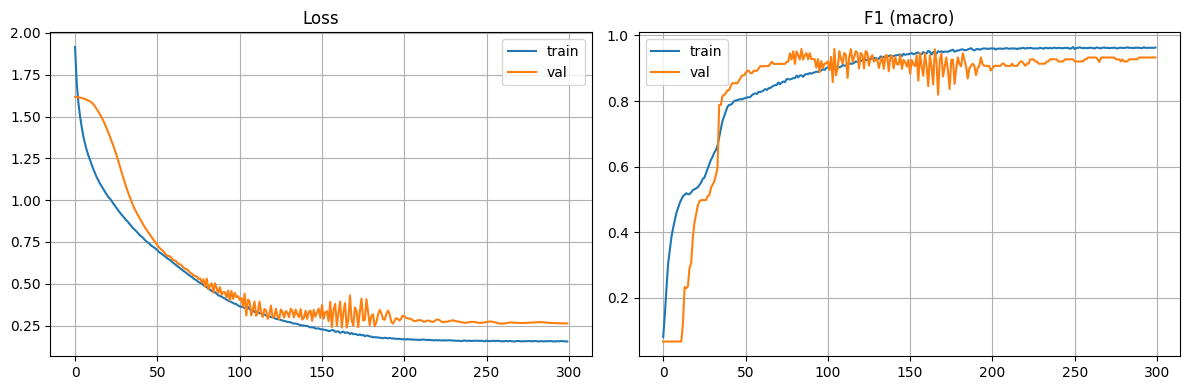

Training complete. Best val F1 = 0.9589 at epoch 105
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     1.0000    0.9412    0.9697        34
           1     1.0000    1.0000    1.0000        34
           2     0.9444    1.0000    0.9714        34
           3     1.0000    0.8529    0.9206        34
           4     0.8718    1.0000    0.9315        34

    accuracy                         0.9588       170
   macro avg     0.9632    0.9588    0.9587       170
weighted avg     0.9632    0.9588    0.9587       170

Overall Accuracy: 0.9588
Macro Precision: 0.9632
Macro Recall:    0.9588
Macro F1:        0.9587
Данных для дообучения: 10 окон
Epoch 5/20, Loss: 0.0328
Epoch 10/20, Loss: 0.0282
Epoch 15/20, Loss: 0.0231
Epoch 20/20, Loss: 0.0200
Дообучение завершено за 3.83 сек
Macro F1 на тестовом пользователе до дообучения: 0.9587
Macro F1 после дообучения (последний слой): 1.0000





Training: 100%|██████| 300/300 [03:54<00:00,  1.28epoch/s, TL=0.128, VL=0.100, VF=0.988, best VF=0.988, best Epoch=106]


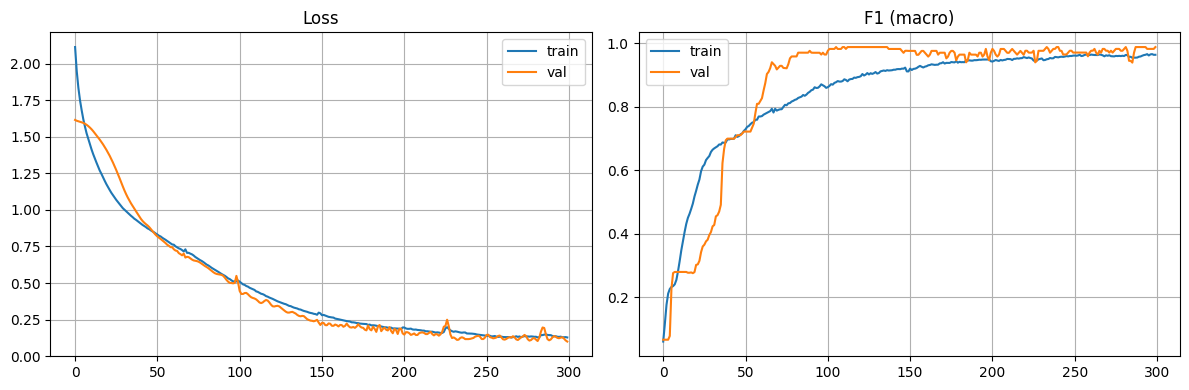

Training complete. Best val F1 = 0.9881 at epoch 106
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     1.0000    0.9412    0.9697        34
           1     1.0000    0.9706    0.9851        34
           2     0.8966    0.7647    0.8254        34
           3     0.8611    0.9118    0.8857        34
           4     0.7500    0.8824    0.8108        34

    accuracy                         0.8941       170
   macro avg     0.9015    0.8941    0.8953       170
weighted avg     0.9015    0.8941    0.8953       170

Overall Accuracy: 0.8941
Macro Precision: 0.9015
Macro Recall:    0.8941
Macro F1:        0.8953
Данных для дообучения: 10 окон
Epoch 5/20, Loss: 0.0684
Epoch 10/20, Loss: 0.0333
Epoch 15/20, Loss: 0.0292
Epoch 20/20, Loss: 0.0230
Дообучение завершено за 3.85 сек
Macro F1 на тестовом пользователе до дообучения: 0.8953
Macro F1 после дообучения (последний слой): 0.9526





Training: 100%|██████| 300/300 [04:00<00:00,  1.25epoch/s, TL=0.111, VL=0.201, VF=0.970, best VF=0.982, best Epoch=288]


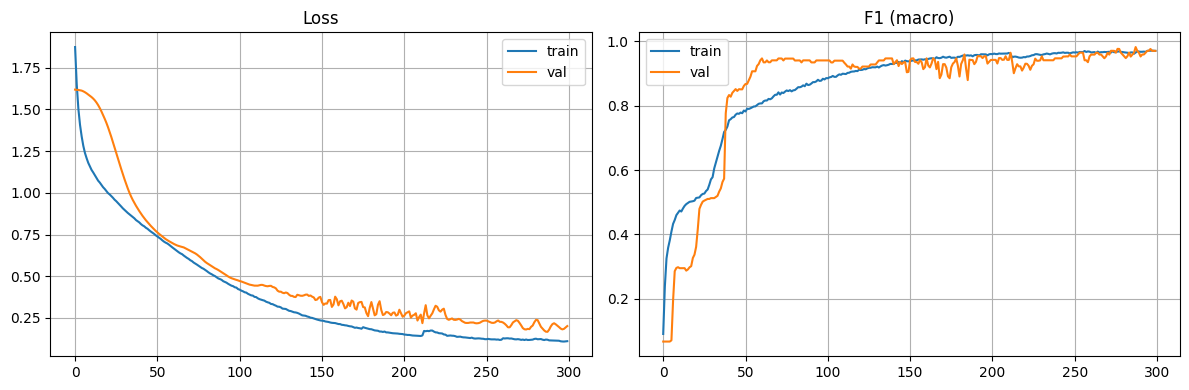

Training complete. Best val F1 = 0.9823 at epoch 288
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     1.0000    0.6176    0.7636        34
           1     1.0000    0.8235    0.9032        34
           2     0.6939    1.0000    0.8193        34
           3     0.4648    0.9706    0.6286        34
           4     0.0000    0.0000    0.0000        34

    accuracy                         0.6824       170
   macro avg     0.6317    0.6824    0.6229       170
weighted avg     0.6317    0.6824    0.6229       170

Overall Accuracy: 0.6824
Macro Precision: 0.6317
Macro Recall:    0.6824
Macro F1:        0.6229
Данных для дообучения: 10 окон
Epoch 5/20, Loss: 0.3205
Epoch 10/20, Loss: 0.2443
Epoch 15/20, Loss: 0.1364
Epoch 20/20, Loss: 0.0759
Дообучение завершено за 3.88 сек
Macro F1 на тестовом пользователе до дообучения: 0.6229
Macro F1 после дообучения (последний слой): 0.9823





Training: 100%|██████| 300/300 [04:00<00:00,  1.25epoch/s, TL=0.171, VL=0.238, VF=0.931, best VF=0.982, best Epoch=129]


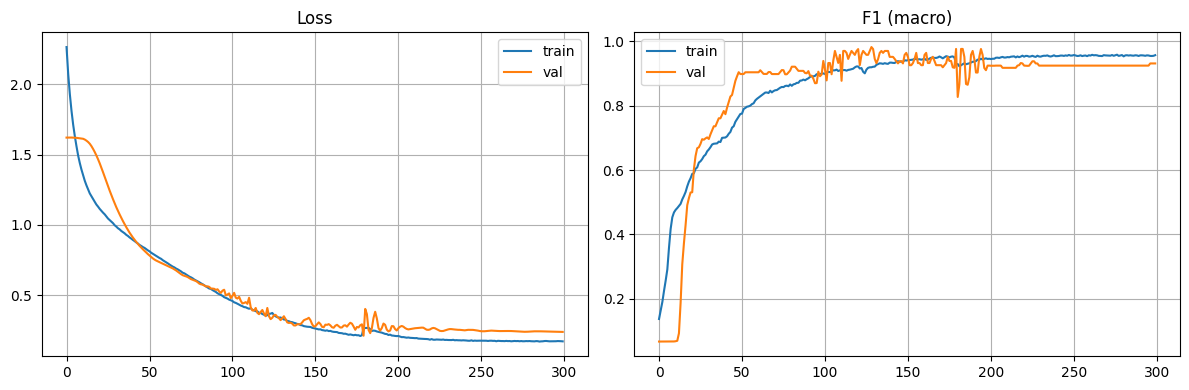

Training complete. Best val F1 = 0.9824 at epoch 129
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     1.0000    0.9706    0.9851        34
           1     1.0000    1.0000    1.0000        34
           2     0.9706    0.9706    0.9706        34
           3     1.0000    1.0000    1.0000        34
           4     0.9714    1.0000    0.9855        34

    accuracy                         0.9882       170
   macro avg     0.9884    0.9882    0.9882       170
weighted avg     0.9884    0.9882    0.9882       170

Overall Accuracy: 0.9882
Macro Precision: 0.9884
Macro Recall:    0.9882
Macro F1:        0.9882
Данных для дообучения: 10 окон
Epoch 5/20, Loss: 0.0530
Epoch 10/20, Loss: 0.0396
Epoch 15/20, Loss: 0.0505
Epoch 20/20, Loss: 0.0368
Дообучение завершено за 3.86 сек
Macro F1 на тестовом пользователе до дообучения: 0.9882
Macro F1 после дообучения (последний слой): 0.9882





Training: 100%|███████| 300/300 [04:00<00:00,  1.25epoch/s, TL=0.201, VL=0.267, VF=0.939, best VF=0.976, best Epoch=96]


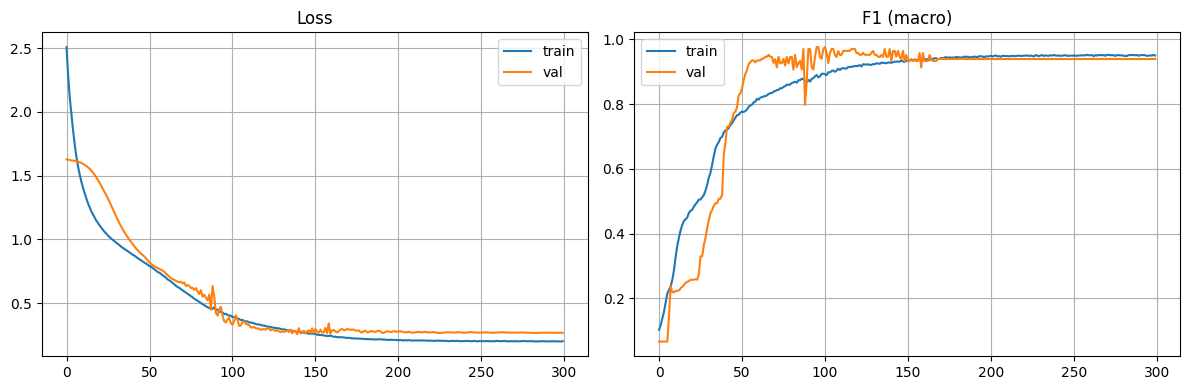

Training complete. Best val F1 = 0.9764 at epoch 96
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.6800    0.5000    0.5763        34
           1     1.0000    0.9706    0.9851        34
           2     0.8438    0.7941    0.8182        34
           3     0.4286    0.1765    0.2500        34
           4     0.3788    0.7353    0.5000        34

    accuracy                         0.6353       170
   macro avg     0.6662    0.6353    0.6259       170
weighted avg     0.6662    0.6353    0.6259       170

Overall Accuracy: 0.6353
Macro Precision: 0.6662
Macro Recall:    0.6353
Macro F1:        0.6259
Данных для дообучения: 10 окон
Epoch 5/20, Loss: 0.3451
Epoch 10/20, Loss: 0.2048
Epoch 15/20, Loss: 0.1775
Epoch 20/20, Loss: 0.1459
Дообучение завершено за 3.89 сек
Macro F1 на тестовом пользователе до дообучения: 0.6259
Macro F1 после дообучения (последний слой): 0.8053



T

Training: 100%|███████| 300/300 [04:00<00:00,  1.25epoch/s, TL=0.152, VL=0.359, VF=0.907, best VF=0.988, best Epoch=58]


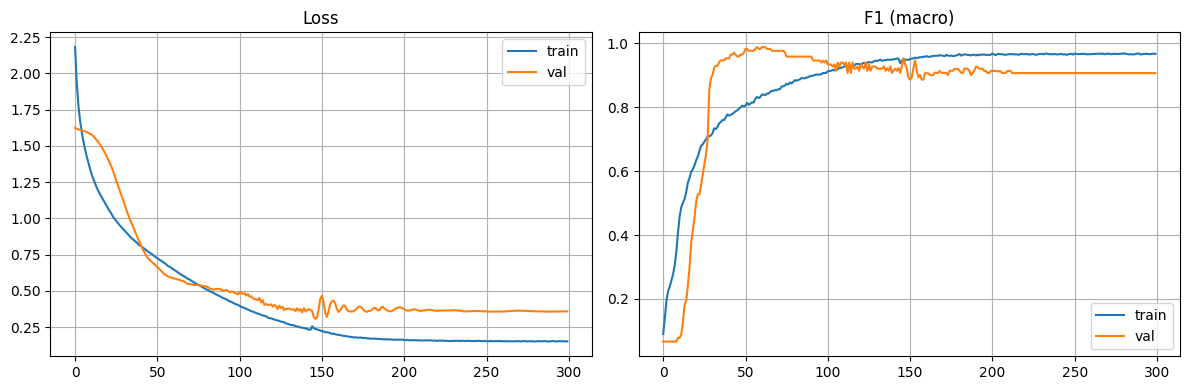

Training complete. Best val F1 = 0.9882 at epoch 58
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.8857    0.9118    0.8986        34
           1     1.0000    1.0000    1.0000        34
           2     0.9091    0.5882    0.7143        34
           3     0.5333    0.4706    0.5000        34
           4     0.6122    0.8824    0.7229        34

    accuracy                         0.7706       170
   macro avg     0.7881    0.7706    0.7671       170
weighted avg     0.7881    0.7706    0.7671       170

Overall Accuracy: 0.7706
Macro Precision: 0.7881
Macro Recall:    0.7706
Macro F1:        0.7671
Данных для дообучения: 10 окон
Epoch 5/20, Loss: 0.2525
Epoch 10/20, Loss: 0.2409
Epoch 15/20, Loss: 0.1650
Epoch 20/20, Loss: 0.1244
Дообучение завершено за 3.86 сек
Macro F1 на тестовом пользователе до дообучения: 0.7671
Macro F1 после дообучения (последний слой): 0.8061



T

Training: 100%|███████| 300/300 [03:59<00:00,  1.25epoch/s, TL=0.185, VL=0.504, VF=0.829, best VF=0.894, best Epoch=70]


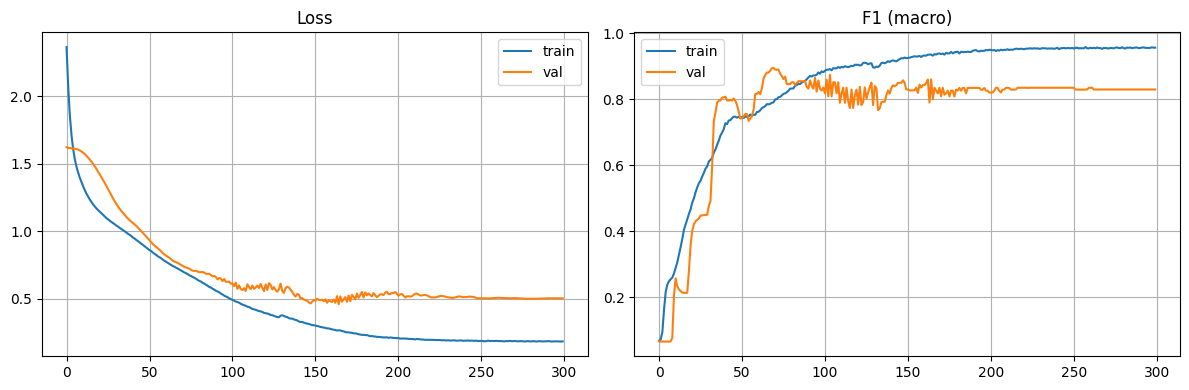

Training complete. Best val F1 = 0.8943 at epoch 70
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9714    1.0000    0.9855        34
           1     1.0000    1.0000    1.0000        34
           2     1.0000    0.9412    0.9697        34
           3     0.0000    0.0000    0.0000        34
           4     0.4928    1.0000    0.6602        34

    accuracy                         0.7882       170
   macro avg     0.6928    0.7882    0.7231       170
weighted avg     0.6928    0.7882    0.7231       170

Overall Accuracy: 0.7882
Macro Precision: 0.6928
Macro Recall:    0.7882
Macro F1:        0.7231
Данных для дообучения: 10 окон


C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

Epoch 5/20, Loss: 0.1788
Epoch 10/20, Loss: 0.1331
Epoch 15/20, Loss: 0.1178
Epoch 20/20, Loss: 0.1136
Дообучение завершено за 3.87 сек
Macro F1 на тестовом пользователе до дообучения: 0.7231
Macro F1 после дообучения (последний слой): 0.9941



Test user: 24
Test user: 24, Val user: 43, Train users: 49
Train windows: 8164, Val windows: 170, Test windows: 170
Class weights: tensor([0.9783, 0.9999, 1.0440, 0.9801, 1.0005])
Total trainable parameters: 13733


Training: 100%|██████| 300/300 [04:02<00:00,  1.24epoch/s, TL=0.105, VL=0.193, VF=0.959, best VF=0.982, best Epoch=192]


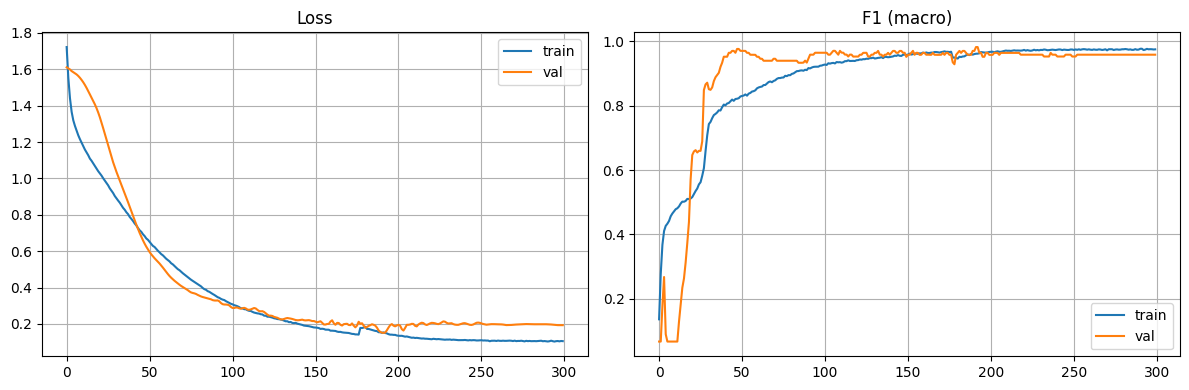

Training complete. Best val F1 = 0.9823 at epoch 192
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        34
           1     1.0000    1.0000    1.0000        34
           2     1.0000    1.0000    1.0000        34
           3     0.3214    0.2647    0.2903        34
           4     0.3750    0.4412    0.4054        34

    accuracy                         0.7412       170
   macro avg     0.7393    0.7412    0.7391       170
weighted avg     0.7393    0.7412    0.7391       170

Overall Accuracy: 0.7412
Macro Precision: 0.7393
Macro Recall:    0.7412
Macro F1:        0.7391
Данных для дообучения: 10 окон
Epoch 5/20, Loss: 0.4214
Epoch 10/20, Loss: 0.2497
Epoch 15/20, Loss: 0.1852
Epoch 20/20, Loss: 0.1253
Дообучение завершено за 3.83 сек
Macro F1 на тестовом пользователе до дообучения: 0.7391
Macro F1 после дообучения (последний слой): 0.7660





Training: 100%|██████| 300/300 [03:56<00:00,  1.27epoch/s, TL=0.128, VL=0.207, VF=0.964, best VF=0.970, best Epoch=125]


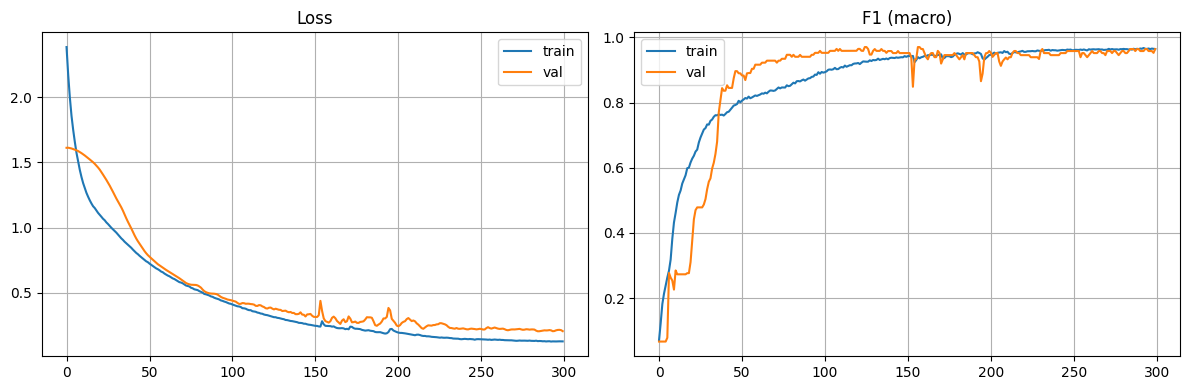

Training complete. Best val F1 = 0.9703 at epoch 125
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.6087    0.8235    0.7000        34
           1     1.0000    0.1176    0.2105        34
           2     0.7619    0.4706    0.5818        34
           3     0.3404    0.9412    0.5000        34
           4     0.0000    0.0000    0.0000        34

    accuracy                         0.4706       170
   macro avg     0.5422    0.4706    0.3985       170
weighted avg     0.5422    0.4706    0.3985       170

Overall Accuracy: 0.4706
Macro Precision: 0.5422
Macro Recall:    0.4706
Macro F1:        0.3985
Данных для дообучения: 10 окон
Epoch 5/20, Loss: 0.7954
Epoch 10/20, Loss: 0.5364
Epoch 15/20, Loss: 0.4820
Epoch 20/20, Loss: 0.3788
Дообучение завершено за 3.83 сек
Macro F1 на тестовом пользователе до дообучения: 0.3985
Macro F1 после дообучения (последний слой): 0.7320





Training: 100%|██████| 300/300 [04:02<00:00,  1.24epoch/s, TL=0.176, VL=0.386, VF=0.892, best VF=0.939, best Epoch=118]


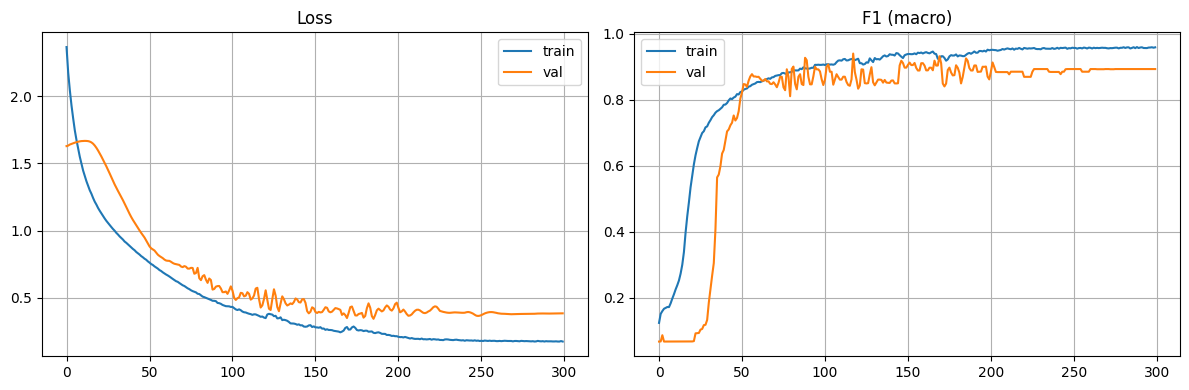

Training complete. Best val F1 = 0.9392 at epoch 118
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9706    0.9706    0.9706        34
           1     1.0000    1.0000    1.0000        34
           2     1.0000    0.9706    0.9851        34
           3     1.0000    0.1176    0.2105        34
           4     0.5231    1.0000    0.6869        34

    accuracy                         0.8118       170
   macro avg     0.8987    0.8118    0.7706       170
weighted avg     0.8987    0.8118    0.7706       170

Overall Accuracy: 0.8118
Macro Precision: 0.8987
Macro Recall:    0.8118
Macro F1:        0.7706
Данных для дообучения: 10 окон
Epoch 5/20, Loss: 0.1471
Epoch 10/20, Loss: 0.1049
Epoch 15/20, Loss: 0.0870
Epoch 20/20, Loss: 0.0828
Дообучение завершено за 3.87 сек
Macro F1 на тестовом пользователе до дообучения: 0.7706
Macro F1 после дообучения (последний слой): 0.8070





Training: 100%|██████| 300/300 [03:53<00:00,  1.28epoch/s, TL=0.151, VL=0.222, VF=0.965, best VF=0.983, best Epoch=274]


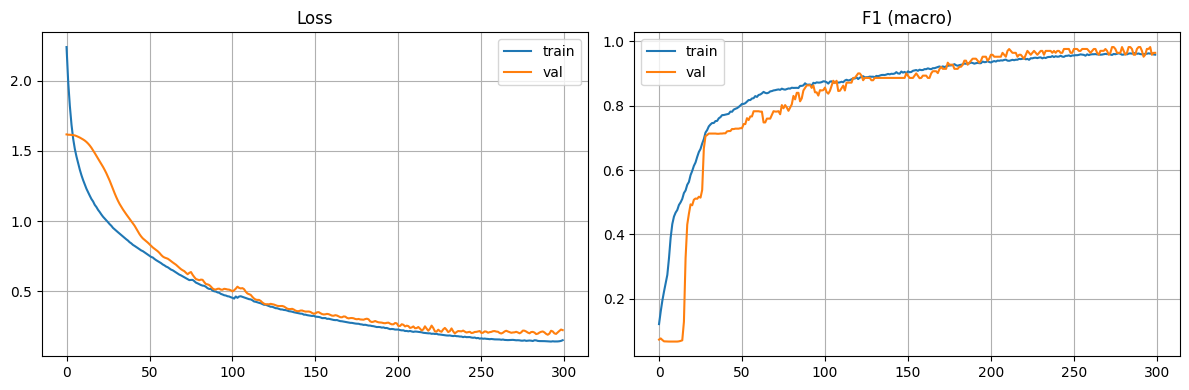

Training complete. Best val F1 = 0.9825 at epoch 274
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9714    1.0000    0.9855        34
           1     1.0000    1.0000    1.0000        34
           2     1.0000    0.5294    0.6923        34
           3     0.9189    1.0000    0.9577        34
           4     0.7391    1.0000    0.8500        34

    accuracy                         0.9059       170
   macro avg     0.9259    0.9059    0.8971       170
weighted avg     0.9259    0.9059    0.8971       170

Overall Accuracy: 0.9059
Macro Precision: 0.9259
Macro Recall:    0.9059
Macro F1:        0.8971
Данных для дообучения: 10 окон
Epoch 5/20, Loss: 0.1723
Epoch 10/20, Loss: 0.0450
Epoch 15/20, Loss: 0.0386
Epoch 20/20, Loss: 0.0620
Дообучение завершено за 3.85 сек
Macro F1 на тестовом пользователе до дообучения: 0.8971
Macro F1 после дообучения (последний слой): 0.8555





Training: 100%|██████| 300/300 [03:53<00:00,  1.29epoch/s, TL=0.222, VL=0.395, VF=0.899, best VF=0.994, best Epoch=132]


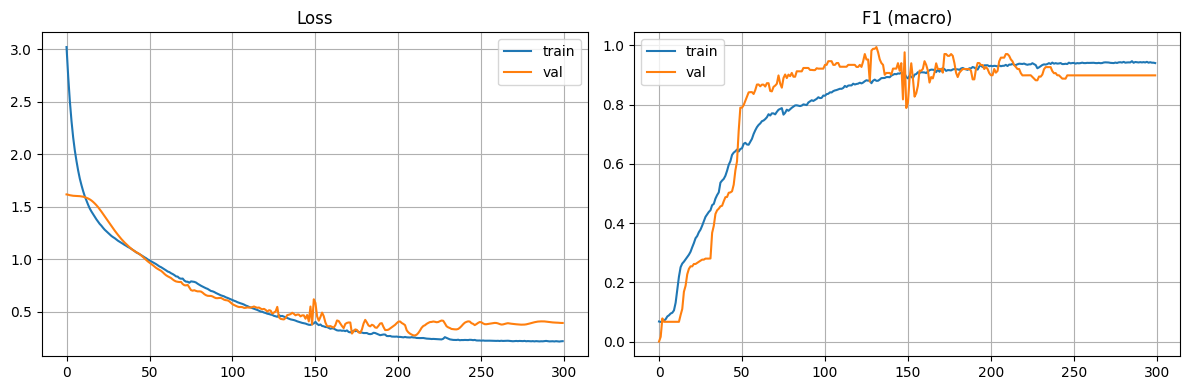

Training complete. Best val F1 = 0.9941 at epoch 132
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.6098    0.7353    0.6667        34
           1     1.0000    0.5000    0.6667        34
           2     0.6562    0.6176    0.6364        34
           3     0.9688    0.9118    0.9394        34
           4     0.6875    0.9706    0.8049        34

    accuracy                         0.7471       170
   macro avg     0.7845    0.7471    0.7428       170
weighted avg     0.7845    0.7471    0.7428       170

Overall Accuracy: 0.7471
Macro Precision: 0.7845
Macro Recall:    0.7471
Macro F1:        0.7428
Данных для дообучения: 10 окон
Epoch 5/20, Loss: 0.4495
Epoch 10/20, Loss: 0.3151
Epoch 15/20, Loss: 0.2460
Epoch 20/20, Loss: 0.1630
Дообучение завершено за 3.85 сек
Macro F1 на тестовом пользователе до дообучения: 0.7428
Macro F1 после дообучения (последний слой): 0.7723





Training: 100%|██████| 300/300 [03:53<00:00,  1.29epoch/s, TL=0.172, VL=0.505, VF=0.649, best VF=0.898, best Epoch=139]


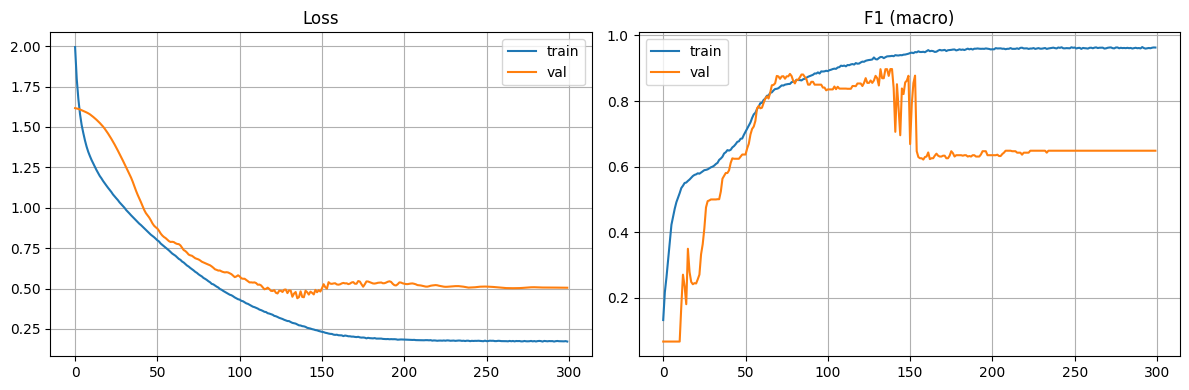

Training complete. Best val F1 = 0.8976 at epoch 139
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9545    0.6176    0.7500        34
           1     1.0000    0.9706    0.9851        34
           2     0.9429    0.9706    0.9565        34
           3     1.0000    0.0294    0.0571        34
           4     0.4304    1.0000    0.6018        34

    accuracy                         0.7176       170
   macro avg     0.8656    0.7176    0.6701       170
weighted avg     0.8656    0.7176    0.6701       170

Overall Accuracy: 0.7176
Macro Precision: 0.8656
Macro Recall:    0.7176
Macro F1:        0.6701
Данных для дообучения: 10 окон
Epoch 5/20, Loss: 0.0907
Epoch 10/20, Loss: 0.0562
Epoch 15/20, Loss: 0.0572
Epoch 20/20, Loss: 0.0649
Дообучение завершено за 3.97 сек
Macro F1 на тестовом пользователе до дообучения: 0.6701
Macro F1 после дообучения (последний слой): 0.8283





Training: 100%|██████| 300/300 [03:53<00:00,  1.29epoch/s, TL=0.199, VL=0.168, VF=0.977, best VF=0.988, best Epoch=154]


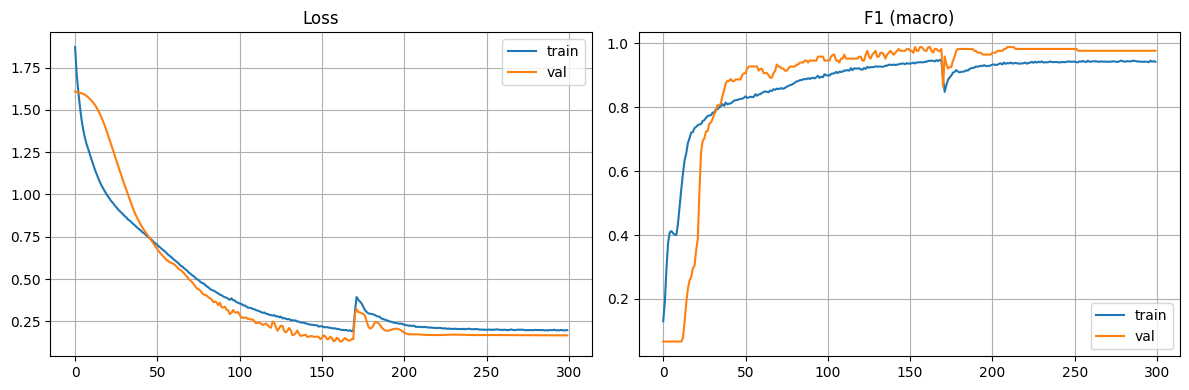

Training complete. Best val F1 = 0.9882 at epoch 154
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.8378    0.9118    0.8732        34
           1     1.0000    0.8235    0.9032        34
           2     0.6471    0.3235    0.4314        34
           3     0.7234    1.0000    0.8395        34
           4     0.6098    0.7353    0.6667        34

    accuracy                         0.7588       170
   macro avg     0.7636    0.7588    0.7428       170
weighted avg     0.7636    0.7588    0.7428       170

Overall Accuracy: 0.7588
Macro Precision: 0.7636
Macro Recall:    0.7588
Macro F1:        0.7428
Данных для дообучения: 10 окон
Epoch 5/20, Loss: 0.3474
Epoch 10/20, Loss: 0.2106
Epoch 15/20, Loss: 0.1945
Epoch 20/20, Loss: 0.1454
Дообучение завершено за 3.85 сек
Macro F1 на тестовом пользователе до дообучения: 0.7428
Macro F1 после дообучения (последний слой): 0.8546





Training: 100%|██████| 300/300 [03:53<00:00,  1.28epoch/s, TL=0.096, VL=0.084, VF=0.971, best VF=0.988, best Epoch=241]


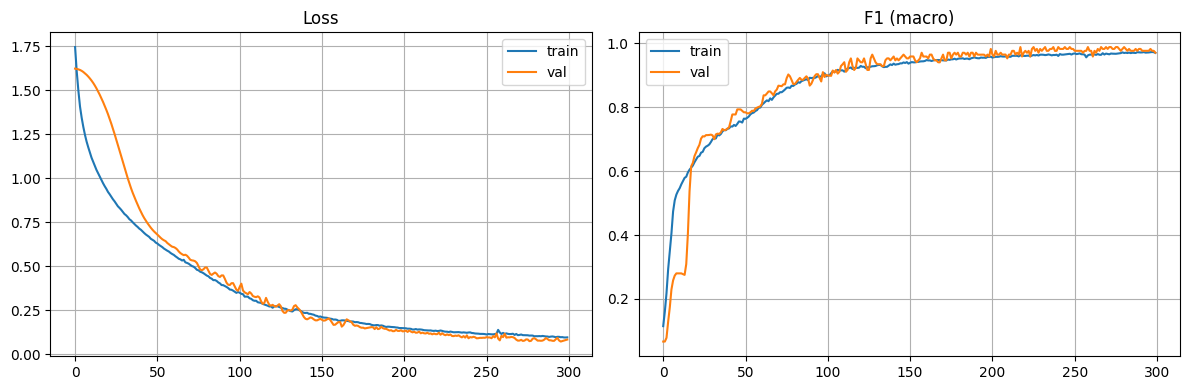

Training complete. Best val F1 = 0.9882 at epoch 241
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000        34
           1     0.5000    1.0000    0.6667        34
           3     0.0000    0.0000    0.0000        34
           4     0.4769    0.9118    0.6263        34

    accuracy                         0.4779       136
   macro avg     0.2442    0.4779    0.3232       136
weighted avg     0.2442    0.4779    0.3232       136

Overall Accuracy: 0.4779
Macro Precision: 0.2442
Macro Recall:    0.4779
Macro F1:        0.3232
Данных для дообучения: 8 окон


C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

Epoch 5/20, Loss: 1.7124
Epoch 10/20, Loss: 1.1313
Epoch 15/20, Loss: 0.5874
Epoch 20/20, Loss: 0.3826
Дообучение завершено за 3.79 сек
Macro F1 на тестовом пользователе до дообучения: 0.3232
Macro F1 после дообучения (последний слой): 0.7385



Test user: 38
Test user: 38, Val user: 43, Train users: 49
Train windows: 8164, Val windows: 170, Test windows: 170
Class weights: tensor([0.9783, 0.9999, 1.0440, 0.9801, 1.0005])
Total trainable parameters: 13733


Training: 100%|██████| 300/300 [03:54<00:00,  1.28epoch/s, TL=0.173, VL=0.236, VF=0.933, best VF=0.939, best Epoch=147]


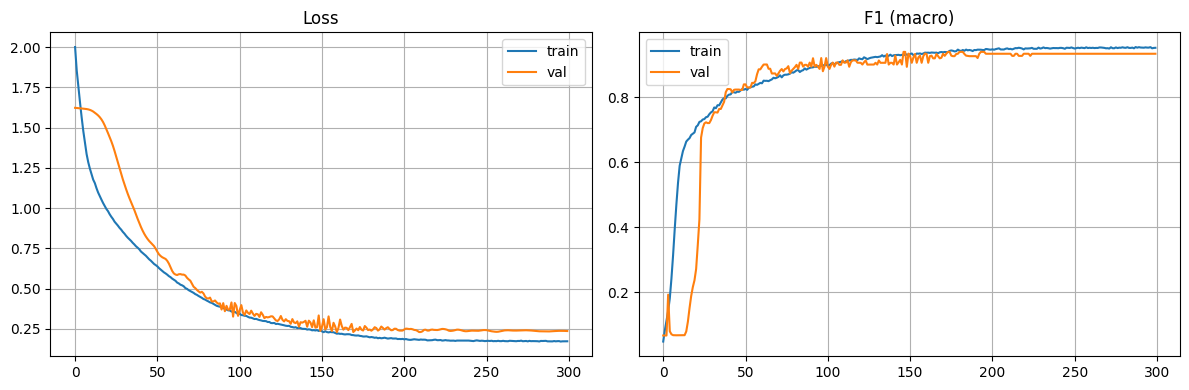

Training complete. Best val F1 = 0.9392 at epoch 147
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.6818    0.4412    0.5357        34
           1     1.0000    0.6471    0.7857        34
           2     0.0000    0.0000    0.0000        34
           3     0.2500    0.0294    0.0526        34
           4     0.3505    1.0000    0.5191        34

    accuracy                         0.4235       170
   macro avg     0.4565    0.4235    0.3786       170
weighted avg     0.4565    0.4235    0.3786       170

Overall Accuracy: 0.4235
Macro Precision: 0.4565
Macro Recall:    0.4235
Macro F1:        0.3786
Данных для дообучения: 10 окон
Epoch 5/20, Loss: 0.6915
Epoch 10/20, Loss: 0.4969
Epoch 15/20, Loss: 0.3214
Epoch 20/20, Loss: 0.2930
Дообучение завершено за 3.84 сек
Macro F1 на тестовом пользователе до дообучения: 0.3786
Macro F1 после дообучения (последний слой): 0.9941





Training: 100%|██████| 300/300 [03:52<00:00,  1.29epoch/s, TL=0.128, VL=0.285, VF=0.928, best VF=0.953, best Epoch=195]


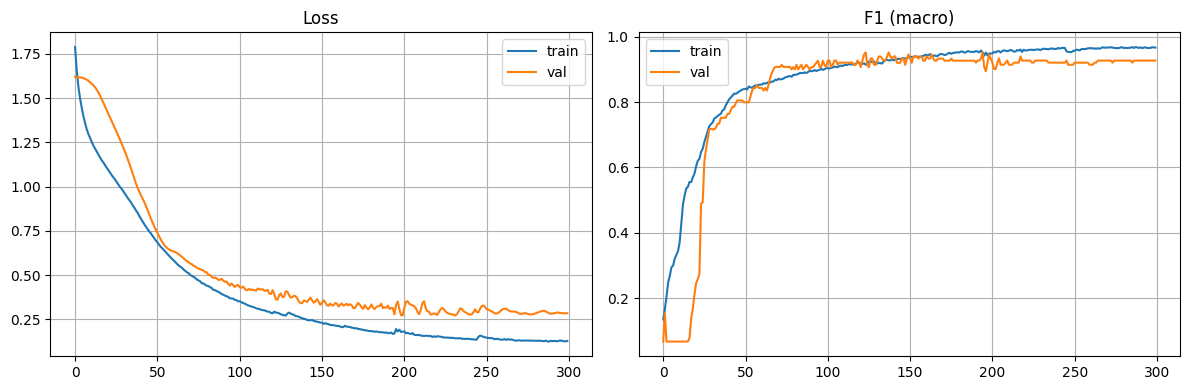

Training complete. Best val F1 = 0.9527 at epoch 195
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.1250    0.0294    0.0476        34
           1     0.4595    1.0000    0.6296        34
           2     0.6154    0.2353    0.3404        34
           3     1.0000    1.0000    1.0000        34
           4     0.8293    1.0000    0.9067        34

    accuracy                         0.6529       170
   macro avg     0.6058    0.6529    0.5849       170
weighted avg     0.6058    0.6529    0.5849       170

Overall Accuracy: 0.6529
Macro Precision: 0.6058
Macro Recall:    0.6529
Macro F1:        0.5849
Данных для дообучения: 10 окон
Epoch 5/20, Loss: 0.3502
Epoch 10/20, Loss: 0.1414
Epoch 15/20, Loss: 0.1486
Epoch 20/20, Loss: 0.1358
Дообучение завершено за 3.84 сек
Macro F1 на тестовом пользователе до дообучения: 0.5849
Macro F1 после дообучения (последний слой): 0.9881





Training: 100%|███████| 300/300 [03:52<00:00,  1.29epoch/s, TL=0.125, VL=0.260, VF=0.929, best VF=0.959, best Epoch=92]


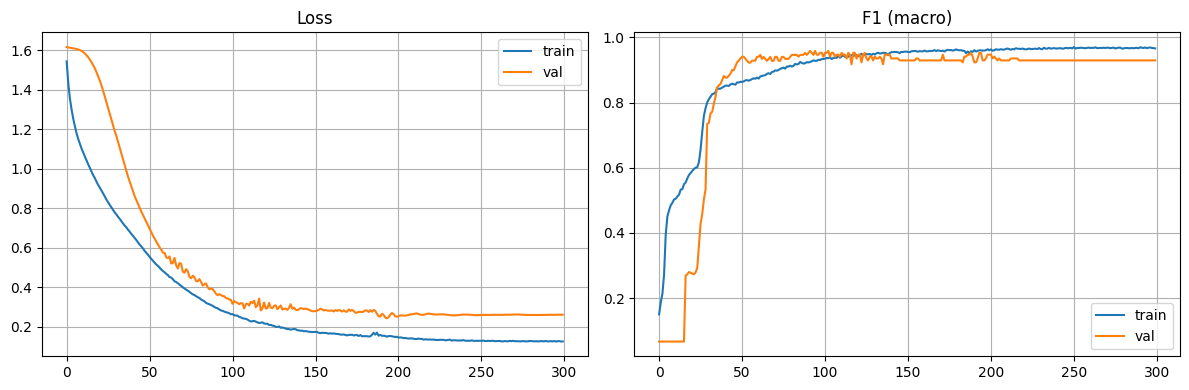

Training complete. Best val F1 = 0.9585 at epoch 92
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     1.0000    0.9118    0.9538        34
           1     1.0000    1.0000    1.0000        34
           3     0.0000    0.0000    0.0000        34
           4     0.0000    0.0000    0.0000         0

    accuracy                         0.6373       102
   macro avg     0.5000    0.4779    0.4885       102
weighted avg     0.6667    0.6373    0.6513       102

Overall Accuracy: 0.6373
Macro Precision: 0.5000
Macro Recall:    0.4779
Macro F1:        0.4885


C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

Данных для дообучения: 6 окон
Epoch 5/20, Loss: 0.5591
Epoch 10/20, Loss: 0.2539
Epoch 15/20, Loss: 0.1908
Epoch 20/20, Loss: 0.1544
Дообучение завершено за 3.82 сек
Macro F1 на тестовом пользователе до дообучения: 0.4885
Macro F1 после дообучения (последний слой): 0.9606



Test user: 41
Test user: 41, Val user: 43, Train users: 49
Train windows: 8164, Val windows: 170, Test windows: 170
Class weights: tensor([0.9783, 0.9999, 1.0440, 0.9801, 1.0005])
Total trainable parameters: 13733


Training: 100%|██████| 300/300 [03:53<00:00,  1.28epoch/s, TL=0.124, VL=0.275, VF=0.947, best VF=0.971, best Epoch=206]


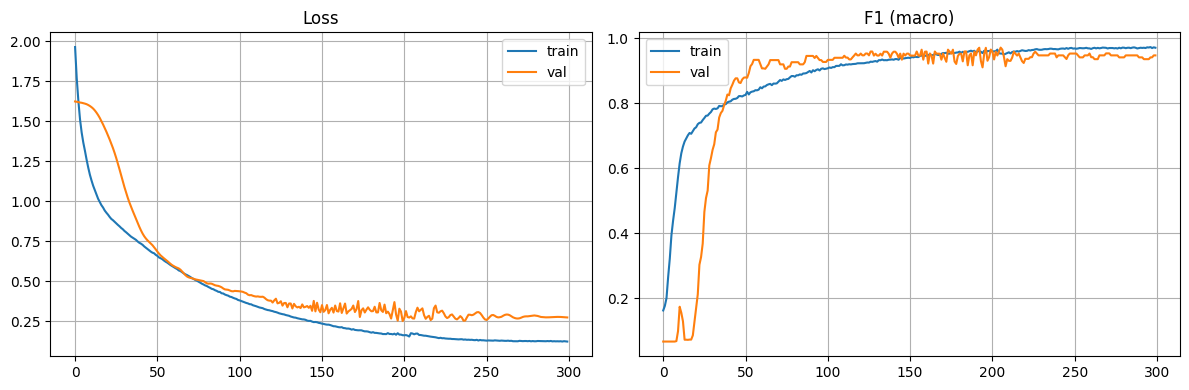

Training complete. Best val F1 = 0.9707 at epoch 206
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     1.0000    0.9706    0.9851        34
           1     1.0000    1.0000    1.0000        34
           2     0.9714    1.0000    0.9855        34
           3     1.0000    0.8824    0.9375        34
           4     0.8947    1.0000    0.9444        34

    accuracy                         0.9706       170
   macro avg     0.9732    0.9706    0.9705       170
weighted avg     0.9732    0.9706    0.9705       170

Overall Accuracy: 0.9706
Macro Precision: 0.9732
Macro Recall:    0.9706
Macro F1:        0.9705
Данных для дообучения: 10 окон
Epoch 5/20, Loss: 0.0264
Epoch 10/20, Loss: 0.0158
Epoch 15/20, Loss: 0.0176
Epoch 20/20, Loss: 0.0128
Дообучение завершено за 3.87 сек
Macro F1 на тестовом пользователе до дообучения: 0.9705
Macro F1 после дообучения (последний слой): 0.9708





Training: 100%|██████| 300/300 [03:53<00:00,  1.29epoch/s, TL=0.104, VL=0.140, VF=0.971, best VF=0.988, best Epoch=231]


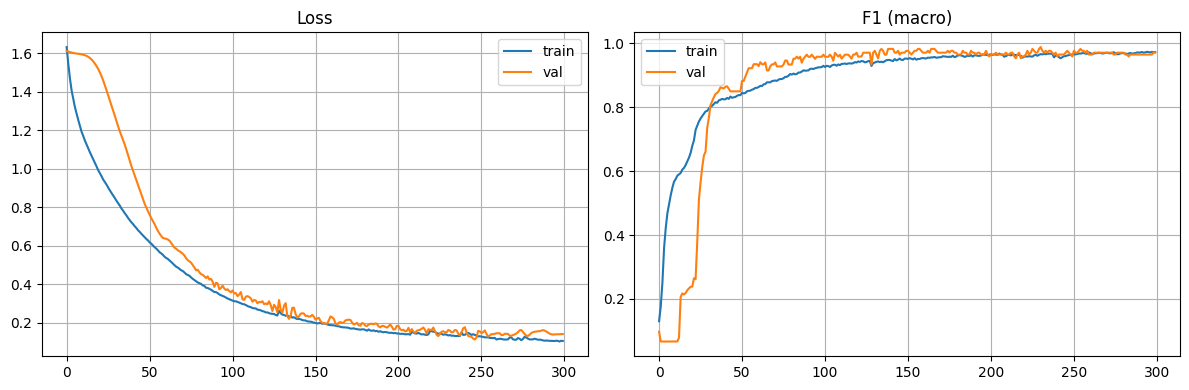

Training complete. Best val F1 = 0.9881 at epoch 231
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     1.0000    0.1176    0.2105        34
           1     1.0000    1.0000    1.0000        34
           2     0.0000    0.0000    0.0000         0
           3     0.9714    1.0000    0.9855        34
           4     0.6296    1.0000    0.7727        34

    accuracy                         0.7794       136
   macro avg     0.7202    0.6235    0.5938       136
weighted avg     0.9003    0.7794    0.7422       136

Overall Accuracy: 0.7794
Macro Precision: 0.7202
Macro Recall:    0.6235
Macro F1:        0.5938
Данных для дообучения: 8 окон


C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

Epoch 5/20, Loss: 0.0376
Epoch 10/20, Loss: 0.0189
Epoch 15/20, Loss: 0.0236
Epoch 20/20, Loss: 0.0180
Дообучение завершено за 3.80 сек
Macro F1 на тестовом пользователе до дообучения: 0.5938
Macro F1 после дообучения (последний слой): 0.7571



Test user: 46
Test user: 46, Val user: 41, Train users: 49
Train windows: 8164, Val windows: 170, Test windows: 170
Class weights: tensor([0.9783, 0.9999, 1.0440, 0.9801, 1.0005])
Total trainable parameters: 13733


Training: 100%|██████| 300/300 [03:53<00:00,  1.29epoch/s, TL=0.134, VL=0.346, VF=0.953, best VF=0.988, best Epoch=188]


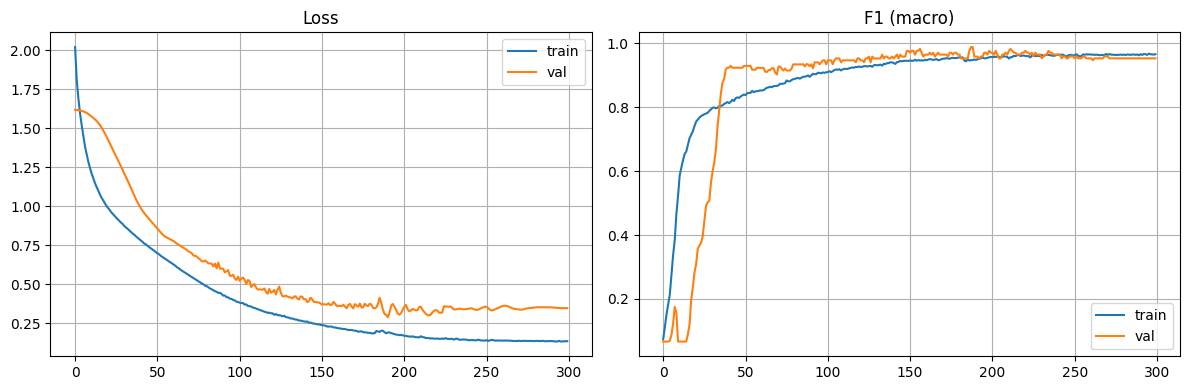

Training complete. Best val F1 = 0.9882 at epoch 188
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.7895    0.8824    0.8333        34
           1     1.0000    0.8529    0.9206        34
           2     0.9688    0.9118    0.9394        34
           3     0.8462    0.3235    0.4681        34
           4     0.5345    0.9118    0.6739        34

    accuracy                         0.7765       170
   macro avg     0.8278    0.7765    0.7671       170
weighted avg     0.8278    0.7765    0.7671       170

Overall Accuracy: 0.7765
Macro Precision: 0.8278
Macro Recall:    0.7765
Macro F1:        0.7671
Данных для дообучения: 10 окон
Epoch 5/20, Loss: 0.0521
Epoch 10/20, Loss: 0.0509
Epoch 15/20, Loss: 0.0208
Epoch 20/20, Loss: 0.0279
Дообучение завершено за 3.83 сек
Macro F1 на тестовом пользователе до дообучения: 0.7671
Macro F1 после дообучения (последний слой): 0.8549





Training: 100%|██████| 300/300 [03:53<00:00,  1.28epoch/s, TL=0.132, VL=0.240, VF=0.935, best VF=0.971, best Epoch=129]


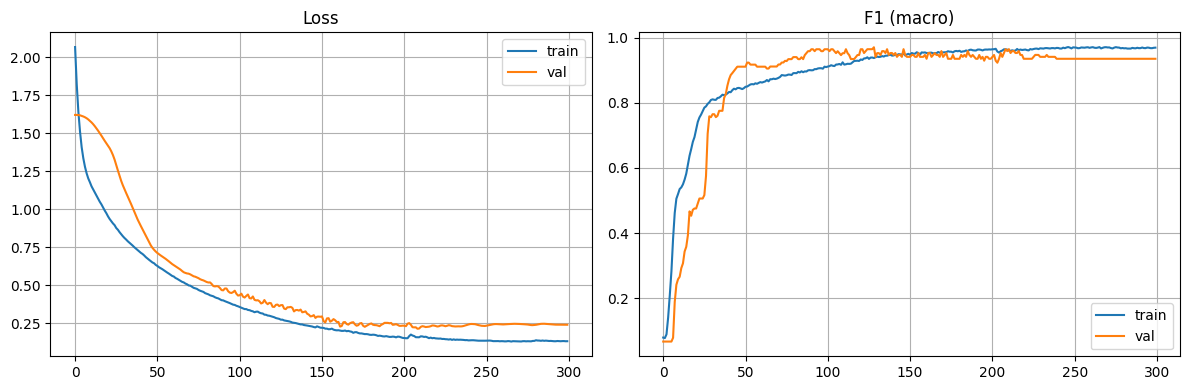

Training complete. Best val F1 = 0.9705 at epoch 129
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9697    0.9412    0.9552        34
           1     0.9714    1.0000    0.9855        34
           2     0.9706    0.9706    0.9706        34
           3     1.0000    0.3824    0.5532        34
           4     0.6182    1.0000    0.7640        34

    accuracy                         0.8588       170
   macro avg     0.9060    0.8588    0.8457       170
weighted avg     0.9060    0.8588    0.8457       170

Overall Accuracy: 0.8588
Macro Precision: 0.9060
Macro Recall:    0.8588
Macro F1:        0.8457
Данных для дообучения: 10 окон
Epoch 5/20, Loss: 0.0431
Epoch 10/20, Loss: 0.0370
Epoch 15/20, Loss: 0.0259
Epoch 20/20, Loss: 0.0260
Дообучение завершено за 3.83 сек
Macro F1 на тестовом пользователе до дообучения: 0.8457
Macro F1 после дообучения (последний слой): 0.8595





Training: 100%|██████| 300/300 [03:57<00:00,  1.27epoch/s, TL=0.209, VL=0.305, VF=0.965, best VF=0.965, best Epoch=160]


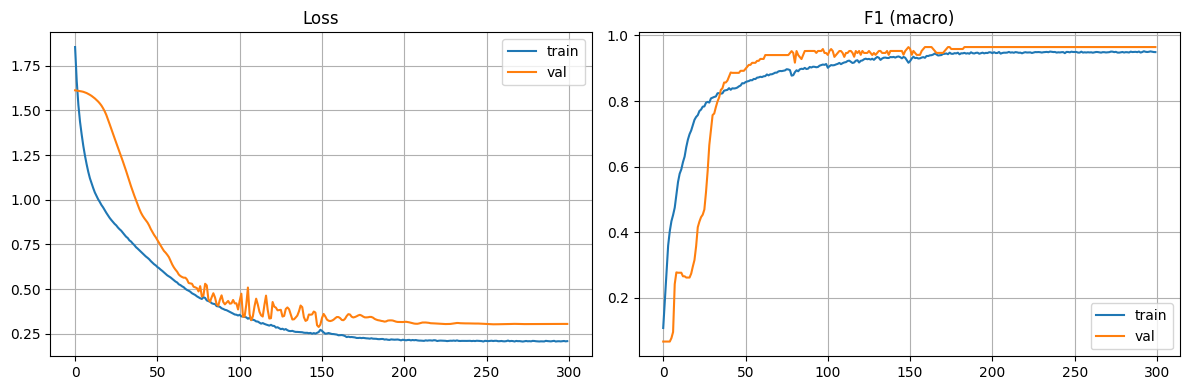

Training complete. Best val F1 = 0.9646 at epoch 160
Model saved to models/siddha_lnn_conv.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.6136    0.7941    0.6923        34
           1     1.0000    1.0000    1.0000        34
           2     0.7500    0.0882    0.1579        34
           3     0.9444    1.0000    0.9714        34
           4     0.6538    1.0000    0.7907        34

    accuracy                         0.7765       170
   macro avg     0.7924    0.7765    0.7225       170
weighted avg     0.7924    0.7765    0.7225       170

Overall Accuracy: 0.7765
Macro Precision: 0.7924
Macro Recall:    0.7765
Macro F1:        0.7225
Данных для дообучения: 10 окон
Epoch 5/20, Loss: 0.3056
Epoch 10/20, Loss: 0.2242
Epoch 15/20, Loss: 0.1801
Epoch 20/20, Loss: 0.1816
Дообучение завершено за 3.84 сек
Macro F1 на тестовом пользователе до дообучения: 0.7225
Macro F1 после дообучения (последний слой): 0.7660





In [5]:
# Take a test user which macro f1 is small (user 27)
# Train model without this user and fitune last liear layer 

test_users = [0, 1, 3, 4, 5, 6, 7, 8, 9, 13, 14, 20, 21, 22, 24, 28, 29, 31, 33, 34, 36, 37, 38, 39, 40, 41, 42, 46, 47, 48]

test_users_metrics = dict()

print(f'Test users (which macro f1 is small): {test_users}')
print(f'Test users count: {len(test_users)}')

for test_user in test_users:
    print(f'\n\n\nTest user: {test_user}')
    
    model, X_test_scaled, y_test = train_by_test_user(test_user)
    
    device = 'cpu'  # принудительно CPU
    finetuned_model = finetune_last_layer(
        base_model=model,
        X_user=X_test_scaled,
        y_user=y_test,
        num_samples_per_class=2,
        epochs=20,
        lr=1e-4
    )
    
    # В примере использования:
    f1_before = evaluate_model(model, X_test_scaled, y_test, device='cpu')
    f1_after = evaluate_model(finetuned_model, X_test_scaled, y_test, device='cpu')
    print(f"Macro F1 на тестовом пользователе до дообучения: {f1_before:.4f}")
    print(f"Macro F1 после дообучения (последний слой): {f1_after:.4f}")
    test_users_metrics[test_user] = (f1_before, f1_after)

print('\n\n\n\n')
sum_f1_before = 0
sum_f1_after = 0
for user in test_users_metrics:
    print(f'\nTest user: {user}')
    print(f"Macro F1 на тестовом пользователе до дообучения: {test_users_metrics[user][0]:.4f}")
    print(f"Macro F1 после дообучения (последний слой): {test_users_metrics[user][1]:.4f}")
    sum_f1_before += test_users_metrics[user][0]
    sum_f1_after += test_users_metrics[user][1]

print(f'\n\n\nMean macro f1 for test users before finetue: {sum_f1_before/len(test_users_metrics):.4f}')
print(f'Mean macro f1 for test users after finetue: {sum_f1_after/len(test_users_metrics):.4f}')

In [7]:
before_f1_list = []
after_f1_list = []
for user in test_users_metrics:
    before_f1_list.append(test_users_metrics[user][0])
    after_f1_list.append(test_users_metrics[user][1])

print(f'Befor finetune macro f1: mean = {np.mean(before_f1_list):.4f}, std = {np.std(before_f1_list):.4f}')
print(f'Befor finetune macro f1: mean = {np.mean(after_f1_list):.4f}, std = {np.std(after_f1_list):.4f}')

Befor finetune macro f1: mean = 0.7367, std = 0.1792
Befor finetune macro f1: mean = 0.8899, std = 0.0938
